In [2]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google'

In [ ]:
import pandas as pd

data=  pd.read_csv('/content/drive/My Drive/diabetes_prediction_dataset.csv')
data.head(3)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0


In [ ]:
print('class wise count')
print(data['diabetes'].value_counts())

class wise count
diabetes
0    91500
1     8500
Name: count, dtype: int64


In [ ]:
!pip install imbalanced-learn


In [ ]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X = data.drop('diabetes', axis=1)
y = data['diabetes']

# Before SMOTE, convert categorical → numeric (encoding)
X_encoded = pd.get_dummies(X, drop_first=True)

# Apply SMOTE
X_res, y_res = sm.fit_resample(X_encoded, y)

print("After SMOTE:")
print(y_res.value_counts())


After SMOTE:
diabetes
0    91500
1    91500
Name: count, dtype: int64


Train/Test split + Scaling

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Train–test split on SMOTE data
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt

def train_eval_model(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    # scores for ROC
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_score)

    print(f"\n=== {model_name} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")

    fpr, tpr, _ = roc_curve(y_test, y_score)
    plt.figure()
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier   # if error:  !pip install xgboost



=== Logistic Regression ===
Accuracy : 0.9147
Precision: 0.9152
Recall   : 0.9140
F1-score : 0.9146
ROC-AUC  : 0.9765


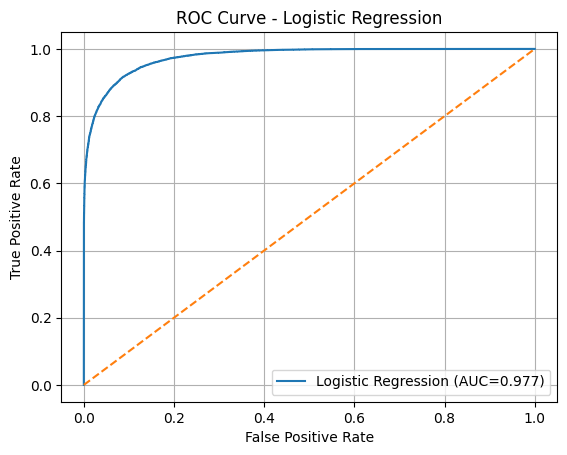

In [ ]:
log_reg = LogisticRegression(max_iter=1000)
train_eval_model(log_reg, X_train_scaled, X_test_scaled,
                 y_train, y_test, "Logistic Regression")



=== K-Nearest Neighbors ===
Accuracy : 0.9461
Precision: 0.9329
Recall   : 0.9614
F1-score : 0.9469
ROC-AUC  : 0.9833


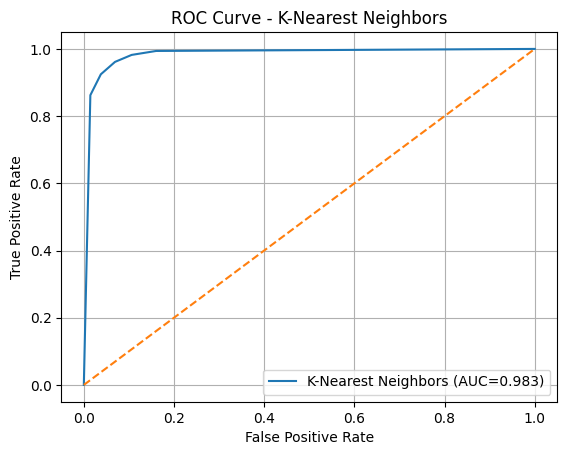

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
train_eval_model(knn, X_train_scaled, X_test_scaled,
                 y_train, y_test, "K-Nearest Neighbors")



=== AdaBoost ===
Accuracy : 0.9267
Precision: 0.9166
Recall   : 0.9389
F1-score : 0.9276
ROC-AUC  : 0.9852


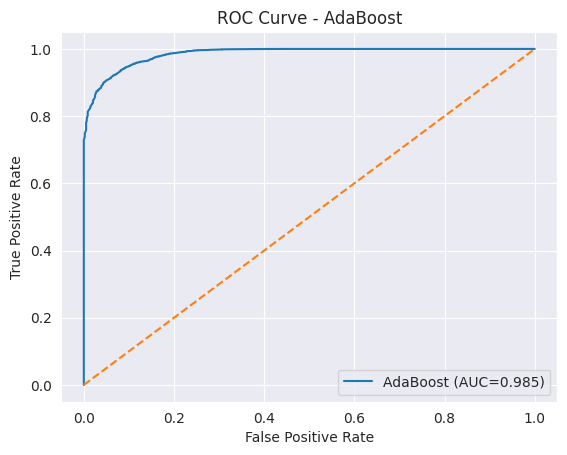

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

base_estimator = DecisionTreeClassifier(max_depth=1, random_state=42)

ab = AdaBoostClassifier(estimator=base_estimator, n_estimators=50, random_state=42)

train_eval_model(ab, X_train_scaled, X_test_scaled,
                 y_train, y_test, "AdaBoost")


=== Naive Bayes ===
Accuracy : 0.8354
Precision: 0.7740
Recall   : 0.9474
F1-score : 0.8520
ROC-AUC  : 0.9305


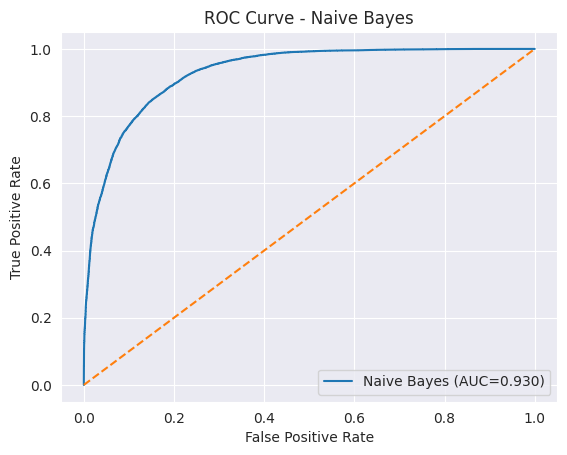

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

train_eval_model(nb, X_train, X_test,
                 y_train, y_test, "Naive Bayes")


=== Decision Tree ===
Accuracy : 0.9566
Precision: 0.9585
Recall   : 0.9545
F1-score : 0.9565
ROC-AUC  : 0.9831


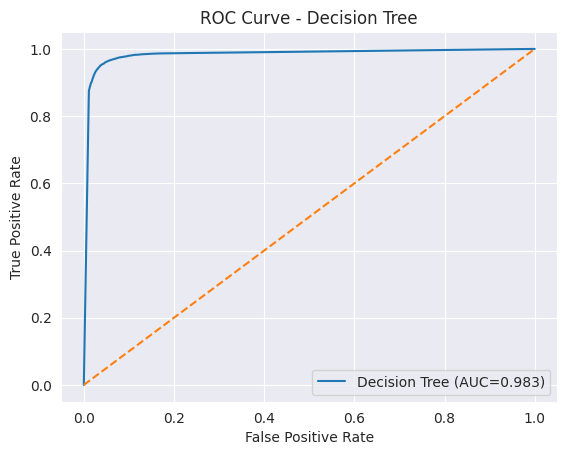

In [ ]:
dt = DecisionTreeClassifier(max_depth=18,random_state=42)
train_eval_model(dt, X_train, X_test,
                 y_train, y_test, "Decision Tree")



=== Random Forest ===
Accuracy : 0.9667
Precision: 0.9666
Recall   : 0.9669
F1-score : 0.9668
ROC-AUC  : 0.9961


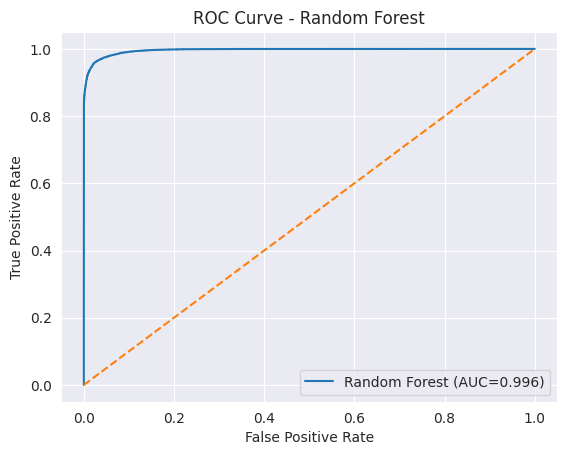

In [ ]:
rf = RandomForestClassifier(n_estimators=200,
    max_depth=20,
    random_state=40)
train_eval_model(rf, X_train, X_test,
                 y_train, y_test, "Random Forest")



=== XGBoost ===
Accuracy : 0.9622
Precision: 0.9769
Recall   : 0.9468
F1-score : 0.9616
ROC-AUC  : 0.9952


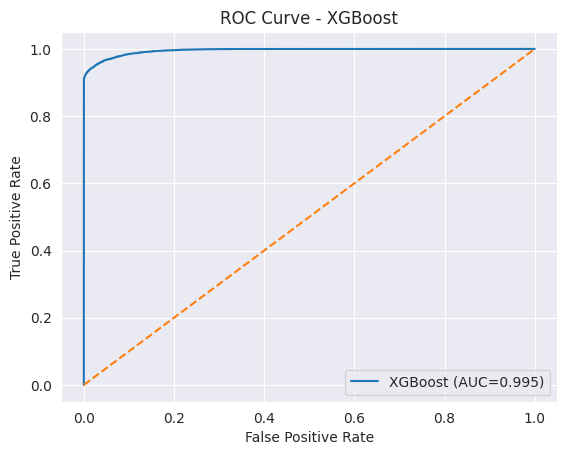

In [ ]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)
train_eval_model(xgb, X_train, X_test,
                 y_train, y_test, "XGBoost")


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [ ]:
ann_model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')   # binary output
])

ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 993 (3.88 KB)

 Trainable params: 993 (3.88 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = ann_model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)
print("Training finished.")


Epoch 1/100
7320/7320 ━━━━━━━━━━━━━━━━━━━━ 30s 4ms/step - accuracy: 0.9167 - loss: 0.1868 - val_accuracy: 0.9232 - val_loss: 0.1669
Epoch 2/100
7320/7320 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - accuracy: 0.9262 - loss: 0.1593 - val_accuracy: 0.9295 - val_loss: 0.1509
Epoch 3/100
7320/7320 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - accuracy: 0.9309 - loss: 0.1475 - val_accuracy: 0.9313 - val_loss: 0.1466
Epoch 4/100
7320/7320 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - accuracy: 0.9327 - loss: 0.1429 - val_accuracy: 0.9323 - val_loss: 0.1450
Epoch 5/100
7320/7320 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.9337 - loss: 0.1397 - val_accuracy: 0.9312 - val_loss: 0.1443
Epoch 6/100
7320/7320 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.9332 - loss: 0.1395 - val_accuracy: 0.9320 - val_loss: 0.1419
Epoch 7/100
7320/7320 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - accuracy: 0.9344 - loss: 0.1385 - val_accuracy: 0.9330 - val_loss: 0.1422
Epoch 8/100
7320/7320 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - accuracy: 0.9355 -

In [ ]:
import numpy as np
print("\n Testing Accuracy ")
np.max(history.history['val_accuracy'])


 Testing Accuracy 


np.float64(0.9419398903846741)

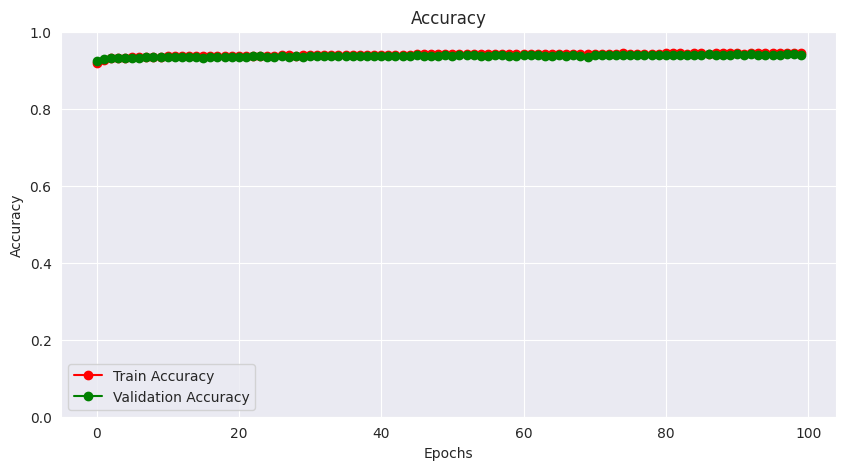

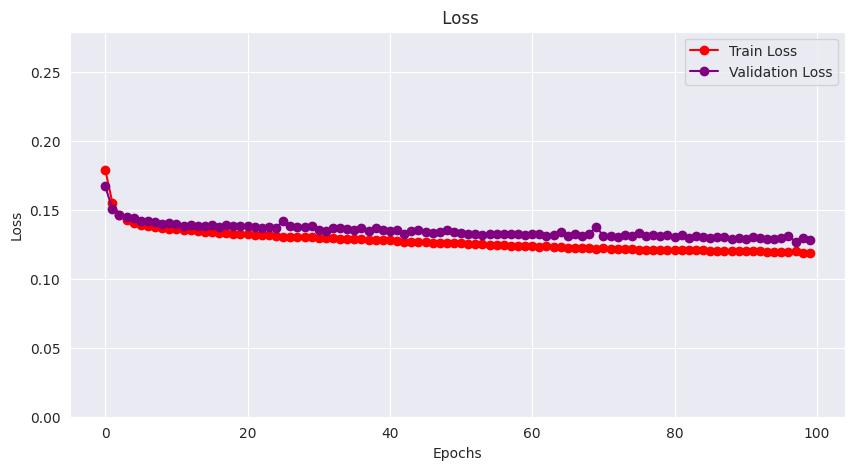

In [ ]:
# ✅ Plot Accuracy & Loss Graphs
import seaborn as sns
sns.set_style("darkgrid")

plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Train Accuracy', color='red', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='green', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy')
plt.legend()
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss', color='red', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', color='purple', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title(' Loss')
plt.legend()
plt.ylim(0, max(history.history['loss']) + 0.1)
plt.show()


In [ ]:
import numpy as np

best_val_acc_epoch = np.argmax(history.history['val_accuracy']) + 1
best_val_acc = np.max(history.history['val_accuracy'])

print(f"Best Validation Accuracy: {best_val_acc:.4f} at Epoch {best_val_acc_epoch}")


Best Validation Accuracy: 0.9419 at Epoch 87


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
rfc = RandomForestClassifier(n_estimators=200,
    max_depth=30,
    random_state=40)
rfc.fit(X_train, y_train)
xgbc = XGBClassifier(
    n_estimators=200,
    random_state=42
)
xgbc.fit(X_train, y_train)
# ✅ Get prediction probabilities from each top model
proba_rf  = rfc.predict_proba(X_test)[:, 1]
proba_xgb = xgbc.predict_proba(X_test)[:, 1]
proba_ann = ann_model.predict(X_test_scaled).ravel()    # ANN (on scaled X_test)

# ✅ Soft-voting ensemble: simple average of probabilities
avg_proba = (proba_rf + proba_xgb + proba_ann) / 3.0

# Convert probabilities to class labels using 0.5 threshold
y_pred_ens = (avg_proba >= 0.5).astype(int)

# ✅ Evaluate ensemble
acc  = accuracy_score(y_test, y_pred_ens)
prec = precision_score(y_test, y_pred_ens)
rec  = recall_score(y_test, y_pred_ens)
f1   = f1_score(y_test, y_pred_ens)
auc  = roc_auc_score(y_test, avg_proba)

print("\n=== Ensemble (RF + XGB + ANN) ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")


1144/1144 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

=== Ensemble (RF + XGB + ANN) ===
Accuracy : 0.9761
Precision: 0.9799
Recall   : 0.9720
F1-score : 0.9760
ROC-AUC  : 0.9975


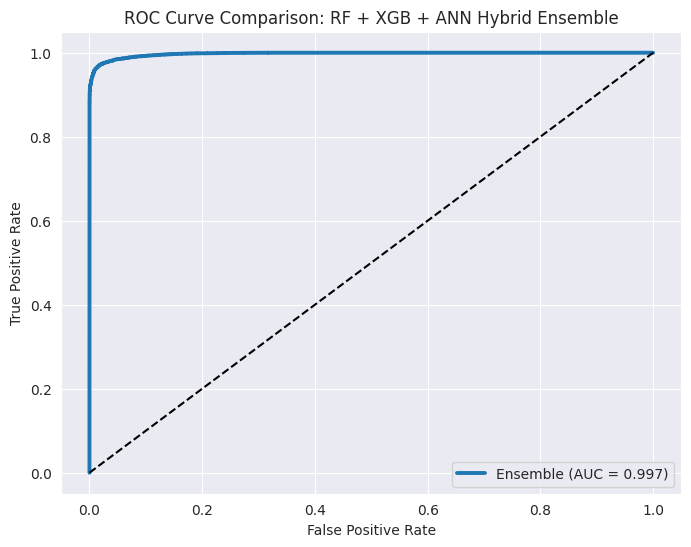

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# --- Compute ROC Curves ---
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, proba_xgb)
fpr_ann, tpr_ann, _ = roc_curve(y_test, proba_ann)
fpr_ens, tpr_ens, _ = roc_curve(y_test, avg_proba)

auc_rf  = auc(fpr_rf,  tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)
auc_ann = auc(fpr_ann, tpr_ann)
auc_ens = auc(fpr_ens, tpr_ens)

# --- Plot ---
plt.figure(figsize=(8,6))

plt.plot(fpr_ens, tpr_ens, label=f"Ensemble (AUC = {auc_ens:.3f})", linewidth=2.8)

plt.plot([0,1], [0,1], 'k--')  # diagonal reference line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: RF + XGB + ANN Hybrid Ensemble")
plt.legend()
plt.grid(True)
plt.show()
